In [1]:
# ── CELL 1: LIBRARY IMPORTS ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── DISPLAY SETTINGS ──
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# ── CELL 2: DATA LOADING ──
df = pd.read_csv('data/DA_task.csv')

# Standardise column names to lowercase
df.columns = df.columns.str.lower()

# Preview
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (170526, 7)

Columns: ['organization_id', 'activity_name', 'timestamp', 'converted', 'converted_at', 'trial_start', 'trial_end']

First 3 rows:


,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [3]:
# ── CELL 3: DATA TYPES AND DATETIME CONVERSION ──
# Convert all datetime columns from string to proper datetime
df['timestamp']    = pd.to_datetime(df['timestamp'])
df['trial_start']  = pd.to_datetime(df['trial_start'])
df['trial_end']    = pd.to_datetime(df['trial_end'])
df['converted_at'] = pd.to_datetime(df['converted_at'])

# Confirm data types
print("Data types after conversion:")
print(df.dtypes)

print("\nDate ranges:")
print(f"  Earliest event:    {df['timestamp'].min()}")
print(f"  Latest event:      {df['timestamp'].max()}")
print(f"  Earliest trial:    {df['trial_start'].min()}")
print(f"  Latest trial end:  {df['trial_end'].max()}")

Data types after conversion:
organization_id            object
activity_name              object
timestamp          datetime64[ns]
converted                    bool
converted_at       datetime64[ns]
trial_start        datetime64[ns]
trial_end          datetime64[ns]
dtype: object

Date ranges:
  Earliest event:    2024-01-01 20:52:26
  Latest event:      2024-04-28 15:10:31
  Earliest trial:    2024-01-01 15:21:50
  Latest trial end:  2024-04-29 21:01:15


In [4]:
# ── CELL 4: MISSING VALUES AND DUPLICATES ──

# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nMissing converted_at as % of total: {df['converted_at'].isnull().mean()*100:.1f}%")

# Duplicates
dupes = df.duplicated().sum()
print(f"\nFully duplicate rows: {dupes}")

# Check for same org + activity + timestamp duplicates
dupes_key = df.duplicated(subset=['organization_id','activity_name','timestamp']).sum()
print(f"Duplicate on org + activity + timestamp: {dupes_key}")

# Organisation level summary
org_summary = df.groupby('organization_id')['converted'].first()
print(f"\nTotal unique organisations: {len(org_summary)}")
print(f"Converted organisations:    {org_summary.sum()}")
print(f"Non-converted organisations:{(~org_summary).sum()}")
print(f"Conversion rate:            {org_summary.mean()*100:.1f}%")

Missing values per column:
organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64

Missing converted_at as % of total: 79.9%

Fully duplicate rows: 67631
Duplicate on org + activity + timestamp: 67631

Total unique organisations: 966
Converted organisations:    206
Non-converted organisations:760
Conversion rate:            21.3%


In [5]:
# ── CELL 5: REMOVE DUPLICATES ──

# Record original size
original_rows = len(df)

# Drop exact duplicates
df = df.drop_duplicates(subset=['organization_id', 'activity_name', 'timestamp'])

# Verify
new_rows = len(df)
removed = original_rows - new_rows

print(f"Rows before deduplication: {original_rows:,}")
print(f"Rows after deduplication:  {new_rows:,}")
print(f"Duplicate rows removed:    {removed:,}")
print(f"Reduction:                 {removed/original_rows*100:.1f}%")

# Confirm conversion rate unchanged
org_summary = df.groupby('organization_id')['converted'].first()
print(f"\nOrganisations after dedup: {len(org_summary)}")
print(f"Conversion rate unchanged: {org_summary.mean()*100:.1f}%")

Rows before deduplication: 170,526
Rows after deduplication:  102,895
Duplicate rows removed:    67,631
Reduction:                 39.7%

Organisations after dedup: 966
Conversion rate unchanged: 21.3%


In [6]:
# ── CELL 6: FEATURE ENGINEERING ──

# Days from trial start to each event
df['days_into_trial'] = (df['timestamp'] - df['trial_start']).dt.days

# Days from trial start to conversion (org level)
df['days_to_convert'] = (df['converted_at'] - df['trial_start']).dt.days

# Trial duration (should be 30 for all — let's verify)
df['trial_duration'] = (df['trial_end'] - df['trial_start']).dt.days

# Flag events that happened BEFORE trial start (data anomaly check)
df['before_trial'] = df['timestamp'] < df['trial_start']

# Flag events that happened AFTER trial end (data anomaly check)
df['after_trial'] = df['timestamp'] > df['trial_end']

print("Derived features created successfully")
print(f"\nTrial duration stats:")
print(df['trial_duration'].describe())

print(f"\nEvents before trial start: {df['before_trial'].sum()}")
print(f"Events after trial end:    {df['after_trial'].sum()}")

print(f"\nDays into trial range:")
print(f"  Min: {df['days_into_trial'].min()}")
print(f"  Max: {df['days_into_trial'].max()}")

print(f"\nDays to convert (converters only):")
print(df[df['converted']==True]['days_to_convert'].describe())

Derived features created successfully

Trial duration stats:
count   102895.00
mean        30.00
std          0.00
min         30.00
25%         30.00
50%         30.00
75%         30.00
max         30.00
Name: trial_duration, dtype: float64

Events before trial start: 0
Events after trial end:    0

Days into trial range:
  Min: 0
  Max: 29

Days to convert (converters only):
count   22223.00
mean       28.08
std         8.09
min        14.00
25%        22.00
50%        25.00
75%        33.00
max        64.00
Name: days_to_convert, dtype: float64


In [7]:
# ── CELL 7: ORGANISATION-LEVEL FEATURE MATRIX ──

# Base org table
org_df = df.groupby('organization_id').agg(
    converted        = ('converted', 'first'),
    trial_start      = ('trial_start', 'first'),
    trial_end        = ('trial_end', 'first'),
    converted_at     = ('converted_at', 'first'),
    days_to_convert  = ('days_to_convert', 'first'),
    total_events     = ('activity_name', 'count'),
    unique_activities= ('activity_name', 'nunique'),
    active_days      = ('days_into_trial', 'nunique'),
    first_event_day  = ('days_into_trial', 'min'),
    last_event_day   = ('days_into_trial', 'max'),
).reset_index()

# Activity breadth ratio (how much of the product did they explore)
org_df['breadth_ratio'] = org_df['unique_activities'] / 28

# Events per active day (intensity)
org_df['event_intensity'] = org_df['total_events'] / org_df['active_days']

print("Organisation feature matrix shape:", org_df.shape)
print(f"\nFeatures created: {org_df.columns.tolist()}")
print("\nSample (first 3 rows):")
org_df.head(3)

Organisation feature matrix shape: (966, 13)

Features created: ['organization_id', 'converted', 'trial_start', 'trial_end', 'converted_at', 'days_to_convert', 'total_events', 'unique_activities', 'active_days', 'first_event_day', 'last_event_day', 'breadth_ratio', 'event_intensity']

Sample (first 3 rows):


,organization_id,converted,trial_start,trial_end,converted_at,days_to_convert,total_events,unique_activities,active_days,first_event_day,last_event_day,breadth_ratio,event_intensity
0,0040dd9ab132b92d5d04bc3acf14d2e2,False,2024-03-27 10:11:39,2024-04-26 10:11:39,NaT,NaN,1004,14,11,0,29,0.50,91.27
1,00456fd86311b6095ad05f7e31758f0d,False,2024-01-11 13:44:36,2024-02-10 13:44:36,NaT,NaN,6,4,1,0,0,0.14,6.00
2,007d48a2bc006e6eac0348c788d26dfd,False,2024-03-16 22:58:07,2024-04-15 22:58:07,NaT,NaN,5,2,2,0,1,0.07,2.50


In [8]:
# ── CELL 8: ACTIVITY PIVOT TABLE ──

# Count of each activity per organisation
activity_pivot = df.pivot_table(
    index='organization_id',
    columns='activity_name',
    values='timestamp',
    aggfunc='count',
    fill_value=0
).reset_index()

# Flatten column names
activity_pivot.columns.name = None

# Binary version — did they do this activity at all? (1/0)
activity_cols = [c for c in activity_pivot.columns if c != 'organization_id']
activity_binary = activity_pivot.copy()
activity_binary[activity_cols] = (activity_pivot[activity_cols] > 0).astype(int)

# Merge both into org_df
org_df = org_df.merge(activity_pivot, on='organization_id', how='left')

print("Activity pivot shape:", activity_pivot.shape)
print(f"\nActivity columns ({len(activity_cols)}):")
for col in activity_cols:
    print(f"  {col}")

print("\nOrg matrix shape after merge:", org_df.shape)

Activity pivot shape: (966, 29)

Activity columns (28):
  Absence.Request.Approved
  Absence.Request.Created
  Absence.Request.Rejected
  Break.Activate.Finished
  Break.Activate.Started
  Communication.Message.Created
  Integration.Xero.PayrollExport.Synced
  Mobile.Schedule.Loaded
  PunchClock.Entry.Edited
  PunchClock.PunchedIn
  PunchClock.PunchedOut
  PunchClockEndNote.Add.Completed
  PunchClockStartNote.Add.Completed
  Revenue.Budgets.Created
  Scheduling.Availability.Set
  Scheduling.OpenShiftRequest.Approved
  Scheduling.OpenShiftRequest.Created
  Scheduling.Shift.Approved
  Scheduling.Shift.AssignmentChanged
  Scheduling.Shift.Created
  Scheduling.ShiftHandover.Accepted
  Scheduling.ShiftHandover.Created
  Scheduling.ShiftSwap.Accepted
  Scheduling.ShiftSwap.Created
  Scheduling.Template.ApplyModal.Applied
  Shift.View.Opened
  ShiftDetails.View.Opened
  Timesheets.BulkApprove.Confirmed

Org matrix shape after merge: (966, 41)


In [9]:
# ── CELL 9: CLEANING SUMMARY AND SANITY CHECK ──

print("=" * 55)
print("   DATA CLEANING SUMMARY")
print("=" * 55)

print(f"\n  Raw rows:              170,526")
print(f"  Duplicate rows removed: 67,631  (39.7%)")
print(f"  Clean rows:            {len(df):,}")
print(f"  Unique organisations:  {org_df.shape[0]:,}")
print(f"  Features per org:      {org_df.shape[1]:,}")
print(f"  Activities tracked:    28")
print(f"  Trial period:          30 days (all orgs)")
print(f"  Date range:            Jan 2024 – Apr 2024")

print(f"\n  Converted orgs:        206  (21.3%)")
print(f"  Non-converted orgs:    760  (78.7%)")

print(f"\n  Avg events (converters):")
print(f"    {org_df[org_df['converted']==True]['total_events'].mean():.0f} events per org")
print(f"\n  Avg events (non-converters):")
print(f"    {org_df[org_df['converted']==False]['total_events'].mean():.0f} events per org")

print(f"\n  Avg unique activities (converters):")
print(f"    {org_df[org_df['converted']==True]['unique_activities'].mean():.1f} activities")
print(f"\n  Avg unique activities (non-converters):")
print(f"    {org_df[org_df['converted']==False]['unique_activities'].mean():.1f} activities")

print("\n  Missing values in org matrix:")
print(org_df[['converted','total_events','unique_activities',
              'active_days','breadth_ratio']].isnull().sum())

print("\n" + "=" * 55)
print("  DATA CLEANING COMPLETE. READY FOR EDA.")
print("=" * 55)

   DATA CLEANING SUMMARY

  Raw rows:              170,526
  Duplicate rows removed: 67,631  (39.7%)
  Clean rows:            102,895
  Unique organisations:  966
  Features per org:      41
  Activities tracked:    28
  Trial period:          30 days (all orgs)
  Date range:            Jan 2024 – Apr 2024

  Converted orgs:        206  (21.3%)
  Non-converted orgs:    760  (78.7%)

  Avg events (converters):
    108 events per org

  Avg events (non-converters):
    106 events per org

  Avg unique activities (converters):
    2.8 activities

  Avg unique activities (non-converters):
    2.8 activities

  Missing values in org matrix:
converted            0
total_events         0
unique_activities    0
active_days          0
breadth_ratio        0
dtype: int64

  DATA CLEANING COMPLETE. READY FOR EDA.


In [10]:
# ── CELL 10: SAVE CLEAN DATA FOR REUSE ──
import os
os.makedirs('data', exist_ok=True)

# Save clean event-level data
df.to_csv('data/clean_events.csv', index=False)

# Save org-level feature matrix
org_df.to_csv('data/org_features.csv', index=False)

print("clean_events.csv saved successfully")
print("org_features.csv saved successfully")
print(f"\nClean events shape: {df.shape}")
print(f"Org features shape: {org_df.shape}")

clean_events.csv saved successfully
org_features.csv saved successfully

Clean events shape: (102895, 12)
Org features shape: (966, 41)


In [11]:
# ── CELL 11: VISUALISATION SETUP ──

# Splendor colour palette
CYAN   = '#00b4d8'
MINT   = '#06d6a0'
AMBER  = '#ffb703'
RED    = '#ff6b6b'
BG     = '#0a0f1e'
SURFACE= '#111827'
MUTED  = '#94a3b8'
TEXT   = '#e2e8f0'
GRID   = '#1f2d40'

# Global matplotlib dark style
plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : SURFACE,
    'axes.edgecolor'    : GRID,
    'axes.labelcolor'   : TEXT,
    'axes.titlecolor'   : TEXT,
    'xtick.color'       : MUTED,
    'ytick.color'       : MUTED,
    'grid.color'        : GRID,
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.7,
    'text.color'        : TEXT,
    'font.family'       : 'sans-serif',
    'legend.facecolor'  : SURFACE,
    'legend.edgecolor'  : GRID,
})

# Save folder
os.makedirs('assets', exist_ok=True)

print("Visualisation settings applied successfully")
print("Assets folder ready")

Visualisation settings applied successfully
Assets folder ready


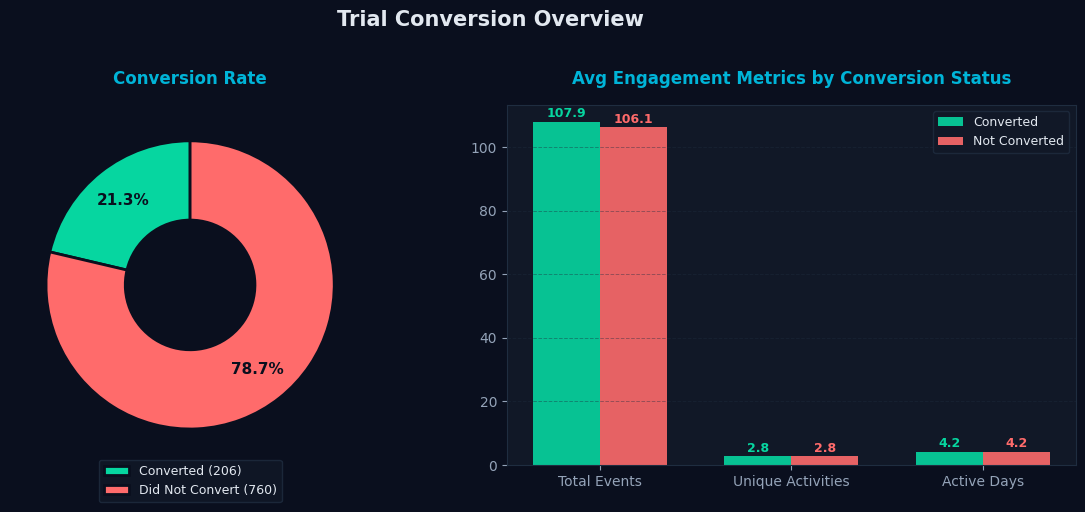

Chart saved: assets/01_conversion_overview.png


In [12]:
# ── CELL 12: CONVERSION OVERVIEW ──

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Trial Conversion Overview', 
             color=TEXT, fontsize=15, fontweight='bold', y=1.02)

# ── CHART 1: Donut chart ──
ax1 = axes[0]
ax1.set_facecolor(SURFACE)

sizes  = [206, 760]
colors = [MINT, RED]
labels = ['Converted (206)', 'Did Not Convert (760)']

wedges, texts, autotexts = ax1.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color(BG)
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax1.legend(wedges, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.12),
           fontsize=9,
           ncol=1)

ax1.set_title('Conversion Rate', color=CYAN,
              fontsize=12, fontweight='bold', pad=15)

# ── CHART 2: Avg events by conversion status ──
ax2 = axes[1]
ax2.set_facecolor(SURFACE)

metrics = ['Total Events', 'Unique Activities', 'Active Days']

conv_vals = [
    org_df[org_df['converted']==True]['total_events'].mean(),
    org_df[org_df['converted']==True]['unique_activities'].mean(),
    org_df[org_df['converted']==True]['active_days'].mean(),
]

nonconv_vals = [
    org_df[org_df['converted']==False]['total_events'].mean(),
    org_df[org_df['converted']==False]['unique_activities'].mean(),
    org_df[org_df['converted']==False]['active_days'].mean(),
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax2.bar(x - width/2, conv_vals,    width, 
                color=MINT, label='Converted',     alpha=0.9, 
                edgecolor='none')
bars2 = ax2.bar(x + width/2, nonconv_vals, width, 
                color=RED,  label='Not Converted', alpha=0.9, 
                edgecolor='none')

# Value labels on bars
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom',
             color=MINT, fontsize=9, fontweight='bold')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom',
             color=RED, fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_title('Avg Engagement Metrics by Conversion Status',
              color=CYAN, fontsize=12, fontweight='bold', pad=15)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.4)
ax2.spines[:].set_color(GRID)

plt.tight_layout()
plt.savefig('assets/01_conversion_overview.png',
            dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()
print("Chart saved: assets/01_conversion_overview.png")

In [16]:
# ── CELL 13: ACTIVITY ADOPTION BY CONVERSION STATUS ──

# Calculate adoption rate for each activity
# (% of orgs that did the activity at least once)
activity_cols = [c for c in org_df.columns if '.' in c or 
                 c in ['Shift.View.Opened', 'ShiftDetails.View.Opened']]

conv    = org_df[org_df['converted'] == True]
nonconv = org_df[org_df['converted'] == False]

adoption = pd.DataFrame({
    'activity'     : activity_cols,
    'conv_rate'    : [(conv[c] > 0).mean() * 100    for c in activity_cols],
    'nonconv_rate' : [(nonconv[c] > 0).mean() * 100 for c in activity_cols],
})

# Difference in adoption rate
adoption['diff'] = adoption['conv_rate'] - adoption['nonconv_rate']

# Sort by difference — biggest gap at top
adoption = adoption.sort_values('diff', ascending=True)

# Short activity names for display
adoption['short_name'] = adoption['activity'].str.split('.').str[-1]

print("Top 10 activities where converters lead:")
print(adoption.tail(10)[['activity','conv_rate',
                          'nonconv_rate','diff']].to_string())

print("\nBottom 5 activities where non-converters lead or equal:")
print(adoption.head(5)[['activity','conv_rate',
                         'nonconv_rate','diff']].to_string())

Top 10 activities where converters lead:
                                  activity  conv_rate  nonconv_rate  diff
14             Scheduling.Availability.Set       6.31          6.05  0.26
18      Scheduling.Shift.AssignmentChanged      35.92         35.39  0.53
2                 Absence.Request.Rejected       1.94          1.32  0.63
20       Scheduling.ShiftHandover.Accepted       1.46          0.79  0.67
17               Scheduling.Shift.Approved      21.36         20.53  0.83
21        Scheduling.ShiftHandover.Created       1.94          0.92  1.02
9                     PunchClock.PunchedIn      23.30         21.45  1.85
16     Scheduling.OpenShiftRequest.Created       6.31          3.95  2.36
24  Scheduling.Template.ApplyModal.Applied      13.11         10.66  2.45
19                Scheduling.Shift.Created      89.81         87.24  2.57

Bottom 5 activities where non-converters lead or equal:
                            activity  conv_rate  nonconv_rate  diff
5      Communication

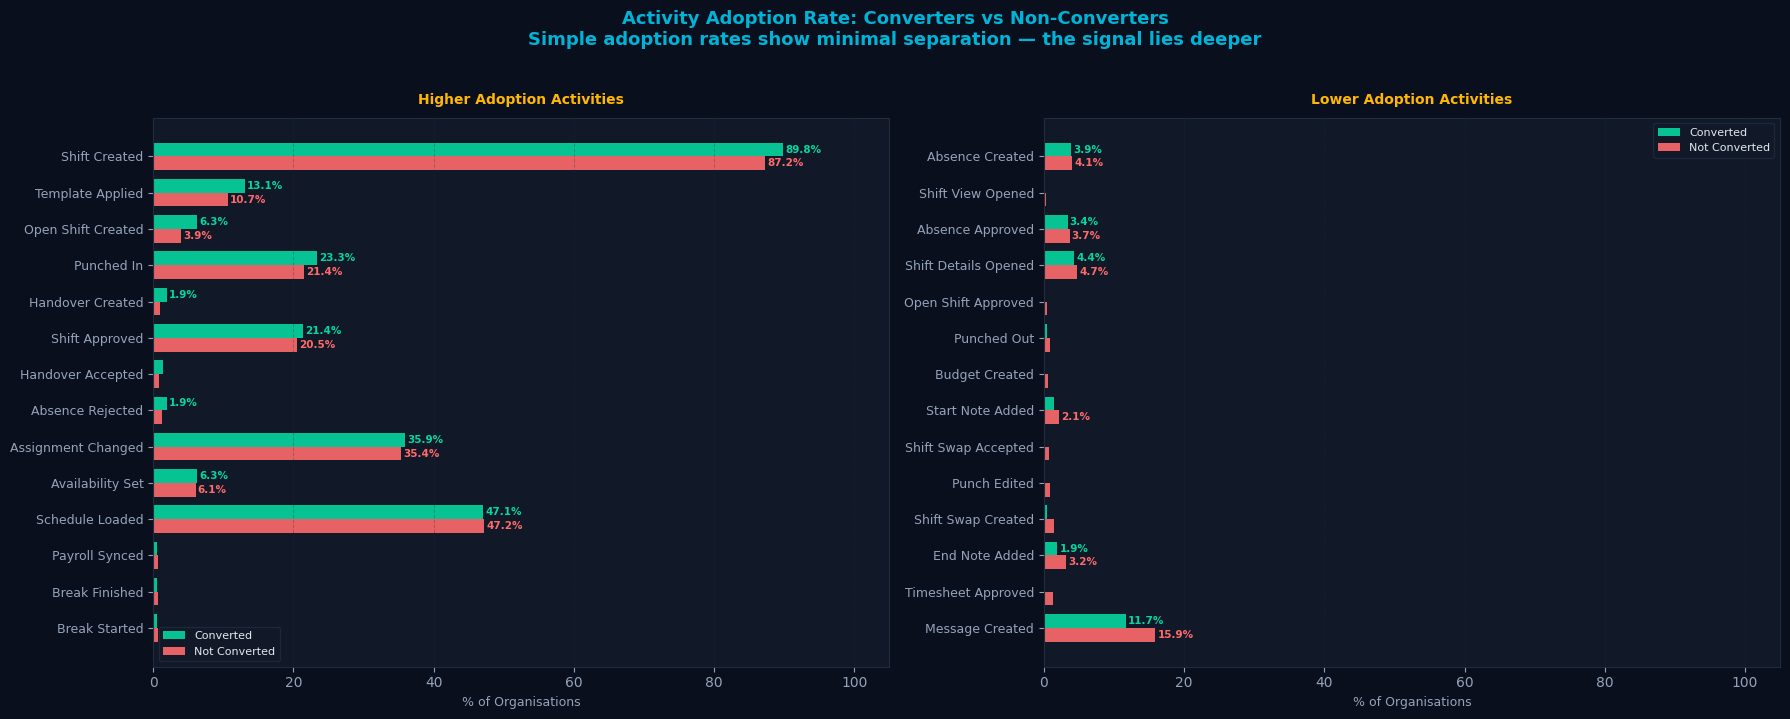

Chart saved: assets/02_activity_adoption.png


In [17]:
# ── CELL 14: ACTIVITY ADOPTION CHART (TWO PANELS) ──

# Create readable labels — must run before plotting
name_map = {
    'Absence.Request.Approved'               : 'Absence Approved',
    'Absence.Request.Created'                : 'Absence Created',
    'Absence.Request.Rejected'               : 'Absence Rejected',
    'Break.Activate.Finished'                : 'Break Finished',
    'Break.Activate.Started'                 : 'Break Started',
    'Communication.Message.Created'          : 'Message Created',
    'Integration.Xero.PayrollExport.Synced'  : 'Payroll Synced',
    'Mobile.Schedule.Loaded'                 : 'Schedule Loaded',
    'PunchClock.Entry.Edited'                : 'Punch Edited',
    'PunchClock.PunchedIn'                   : 'Punched In',
    'PunchClock.PunchedOut'                  : 'Punched Out',
    'PunchClockEndNote.Add.Completed'        : 'End Note Added',
    'PunchClockStartNote.Add.Completed'      : 'Start Note Added',
    'Revenue.Budgets.Created'                : 'Budget Created',
    'Scheduling.Availability.Set'            : 'Availability Set',
    'Scheduling.OpenShiftRequest.Approved'   : 'Open Shift Approved',
    'Scheduling.OpenShiftRequest.Created'    : 'Open Shift Created',
    'Scheduling.Shift.Approved'              : 'Shift Approved',
    'Scheduling.Shift.AssignmentChanged'     : 'Assignment Changed',
    'Scheduling.Shift.Created'               : 'Shift Created',
    'Scheduling.ShiftHandover.Accepted'      : 'Handover Accepted',
    'Scheduling.ShiftHandover.Created'       : 'Handover Created',
    'Scheduling.ShiftSwap.Accepted'          : 'Shift Swap Accepted',
    'Scheduling.ShiftSwap.Created'           : 'Shift Swap Created',
    'Scheduling.Template.ApplyModal.Applied' : 'Template Applied',
    'Shift.View.Opened'                      : 'Shift View Opened',
    'ShiftDetails.View.Opened'               : 'Shift Details Opened',
    'Timesheets.BulkApprove.Confirmed'       : 'Timesheet Approved',
}

adoption['label'] = adoption['activity'].map(name_map)

# Split into top half and bottom half
top_half    = adoption.iloc[14:]  # higher adoption activities
bottom_half = adoption.iloc[:14]  # lower adoption activities

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Activity Adoption Rate: Converters vs Non-Converters\n'
    'Simple adoption rates show minimal separation — the signal lies deeper',
    color=CYAN, fontsize=13, fontweight='bold', y=1.02
)

def draw_adoption_panel(ax, data, title):
    ax.set_facecolor(SURFACE)
    y = np.arange(len(data))
    height = 0.38

    bars1 = ax.barh(y + height/2, data['conv_rate'].values,
                    height, color=MINT, alpha=0.9,
                    label='Converted', edgecolor='none')
    bars2 = ax.barh(y - height/2, data['nonconv_rate'].values,
                    height, color=RED, alpha=0.9,
                    label='Not Converted', edgecolor='none')

    for bar in bars1:
        w = bar.get_width()
        if w > 1.5:
            ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{w:.1f}%', va='center', color=MINT,
                    fontsize=7.5, fontweight='bold')

    for bar in bars2:
        w = bar.get_width()
        if w > 1.5:
            ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{w:.1f}%', va='center', color=RED,
                    fontsize=7.5, fontweight='bold')

    ax.set_yticks(y)
    ax.set_yticklabels(data['label'].values, fontsize=9)
    ax.set_xlabel('% of Organisations', color=MUTED, fontsize=9)
    ax.set_title(title, color=AMBER, fontsize=10,
                 fontweight='bold', pad=10)
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[:].set_color(GRID)
    ax.set_xlim(0, 105)

draw_adoption_panel(ax1, top_half,
                    'Higher Adoption Activities')
draw_adoption_panel(ax2, bottom_half,
                    'Lower Adoption Activities')

plt.tight_layout()
plt.savefig('assets/02_activity_adoption.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart saved: assets/02_activity_adoption.png")

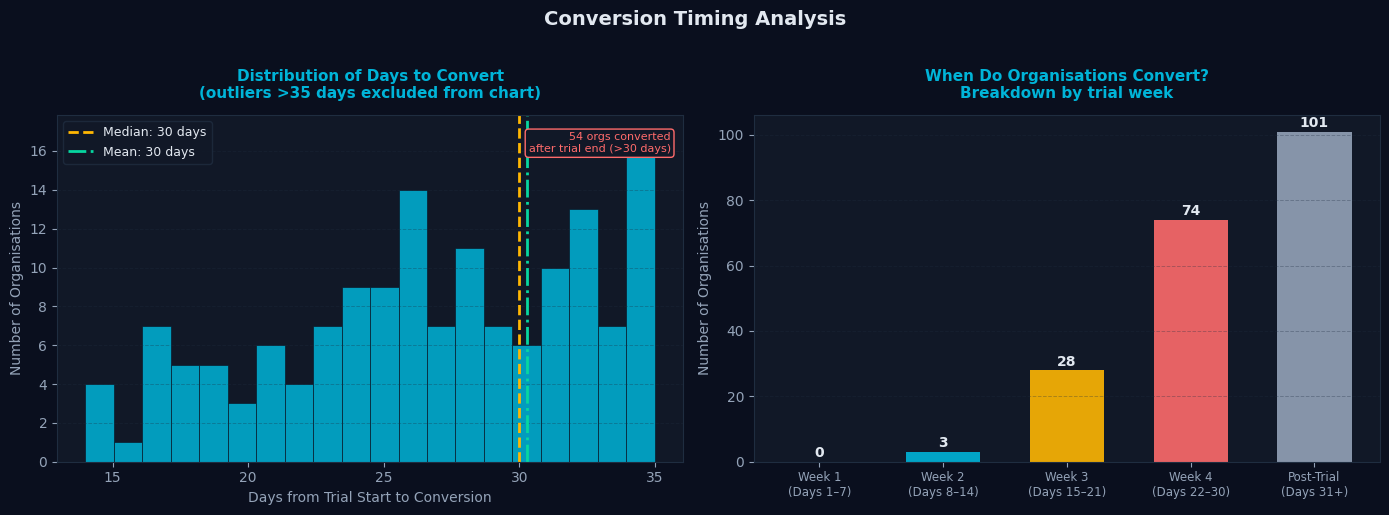

Chart saved: assets/03_conversion_timing.png

Conversion timing summary:
  Median days to convert: 30
  Mean days to convert:   30
  Converted in Week 1:    0
  Converted in Week 4:    74
  Converted post-trial:   101


In [18]:
# ── CELL 15: TIME TO CONVERSION DISTRIBUTION ──

converters = org_df[org_df['converted'] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Conversion Timing Analysis',
             color=TEXT, fontsize=14, fontweight='bold', y=1.02)

# ── CHART 1: Histogram of days to convert ──
ax1 = axes[0]
ax1.set_facecolor(SURFACE)

# Only plot within reasonable range (drop outliers > 35 days)
within_trial = converters[converters['days_to_convert'] <= 35]
late          = converters[converters['days_to_convert'] > 35]

ax1.hist(within_trial['days_to_convert'],
         bins=20, color=CYAN, alpha=0.85,
         edgecolor=BG, linewidth=0.5)

ax1.axvline(converters['days_to_convert'].median(),
            color=AMBER, linewidth=2, linestyle='--',
            label=f"Median: {converters['days_to_convert'].median():.0f} days")

ax1.axvline(converters['days_to_convert'].mean(),
            color=MINT, linewidth=2, linestyle='-.',
            label=f"Mean: {converters['days_to_convert'].mean():.0f} days")

ax1.set_xlabel('Days from Trial Start to Conversion',
               color=MUTED, fontsize=10)
ax1.set_ylabel('Number of Organisations', color=MUTED, fontsize=10)
ax1.set_title('Distribution of Days to Convert\n(outliers >35 days excluded from chart)',
              color=CYAN, fontsize=11, fontweight='bold', pad=12)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[:].set_color(GRID)

ax1.text(0.98, 0.95,
         f'{len(late)} orgs converted\nafter trial end (>30 days)',
         transform=ax1.transAxes,
         color=RED, fontsize=8, ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor=SURFACE, edgecolor=RED))

# ── CHART 2: Conversion by trial week ──
ax2 = axes[1]
ax2.set_facecolor(SURFACE)

# Bin into trial weeks
bins   = [0, 7, 14, 21, 30, 65]
labels = ['Week 1\n(Days 1–7)', 'Week 2\n(Days 8–14)',
          'Week 3\n(Days 15–21)', 'Week 4\n(Days 22–30)',
          'Post-Trial\n(Days 31+)']

converters['week_bin'] = pd.cut(
    converters['days_to_convert'],
    bins=bins, labels=labels, right=True
)

week_counts = converters['week_bin'].value_counts().reindex(labels)
colors_week = [MINT, CYAN, AMBER, RED, MUTED]

bars = ax2.bar(labels, week_counts.values,
               color=colors_week, alpha=0.9,
               edgecolor='none', width=0.6)

for bar, val in zip(bars, week_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', va='bottom',
             color=TEXT, fontsize=10, fontweight='bold')

ax2.set_ylabel('Number of Organisations',
               color=MUTED, fontsize=10)
ax2.set_title('When Do Organisations Convert?\n'
              'Breakdown by trial week',
              color=CYAN, fontsize=11, fontweight='bold', pad=12)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[:].set_color(GRID)
ax2.tick_params(axis='x', labelsize=8.5)

plt.tight_layout()
plt.savefig('assets/03_conversion_timing.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart saved: assets/03_conversion_timing.png")

# Print summary
print(f"\nConversion timing summary:")
print(f"  Median days to convert: {converters['days_to_convert'].median():.0f}")
print(f"  Mean days to convert:   {converters['days_to_convert'].mean():.0f}")
print(f"  Converted in Week 1:    {week_counts.iloc[0]}")
print(f"  Converted in Week 4:    {week_counts.iloc[3]}")
print(f"  Converted post-trial:   {week_counts.iloc[4]}")

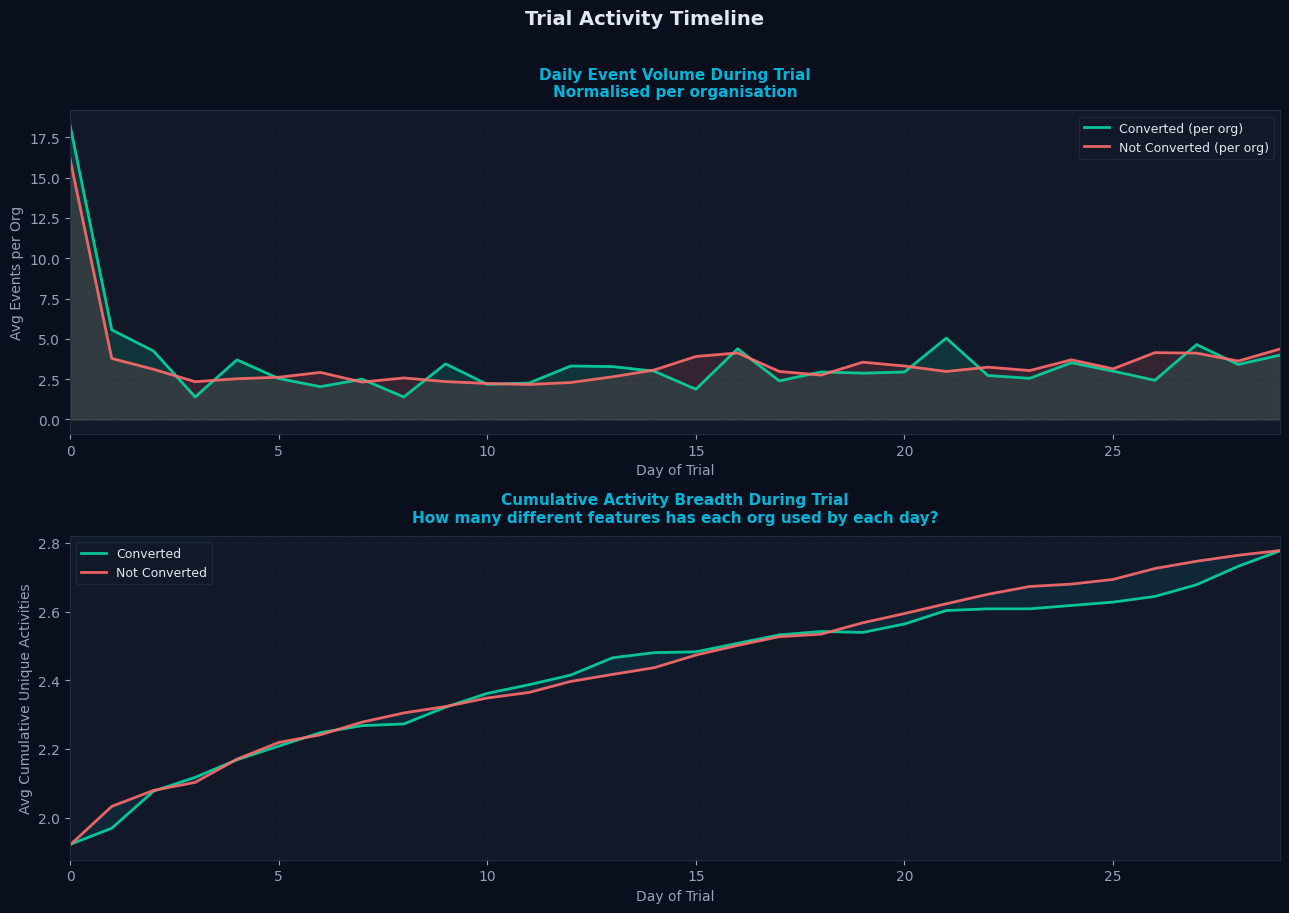

Chart saved: assets/04_activity_timeline.png


In [19]:
# ── CELL 16: ACTIVITY TIMELINE DURING TRIAL ──

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('Trial Activity Timeline',
             color=TEXT, fontsize=14, fontweight='bold', y=1.01)

# ── CHART 1: Daily event volume by conversion status ──
ax1 = axes[0]
ax1.set_facecolor(SURFACE)

daily_conv = df[df['converted']==True].groupby(
    'days_into_trial')['activity_name'].count()
daily_nonconv = df[df['converted']==False].groupby(
    'days_into_trial')['activity_name'].count()

# Normalise by number of orgs
daily_conv_norm    = daily_conv / 206
daily_nonconv_norm = daily_nonconv / 760

ax1.plot(daily_conv_norm.index, daily_conv_norm.values,
         color=MINT, linewidth=2, label='Converted (per org)',
         alpha=0.9)
ax1.plot(daily_nonconv_norm.index, daily_nonconv_norm.values,
         color=RED, linewidth=2, label='Not Converted (per org)',
         alpha=0.9)

ax1.fill_between(daily_conv_norm.index,
                 daily_conv_norm.values, alpha=0.15, color=MINT)
ax1.fill_between(daily_nonconv_norm.index,
                 daily_nonconv_norm.values, alpha=0.15, color=RED)

ax1.set_xlabel('Day of Trial', color=MUTED, fontsize=10)
ax1.set_ylabel('Avg Events per Org', color=MUTED, fontsize=10)
ax1.set_title('Daily Event Volume During Trial\n'
              'Normalised per organisation',
              color=CYAN, fontsize=11, fontweight='bold', pad=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.spines[:].set_color(GRID)
ax1.set_xlim(0, 29)

# ── CHART 2: Cumulative unique activities over trial days ──
ax2 = axes[1]
ax2.set_facecolor(SURFACE)

# For each org, calculate cumulative unique activities by day
conv_orgs    = df[df['converted']==True]
nonconv_orgs = df[df['converted']==False]

# Average cumulative unique activities per day
def avg_cumulative_activities(data):
    result = []
    for day in range(30):
        subset = data[data['days_into_trial'] <= day]
        avg = subset.groupby('organization_id')['activity_name'].nunique().mean()
        result.append(avg)
    return result

conv_cumul    = avg_cumulative_activities(conv_orgs)
nonconv_cumul = avg_cumulative_activities(nonconv_orgs)

days = list(range(30))
ax2.plot(days, conv_cumul, color=MINT, linewidth=2,
         label='Converted', alpha=0.9)
ax2.plot(days, nonconv_cumul, color=RED, linewidth=2,
         label='Not Converted', alpha=0.9)

ax2.fill_between(days, conv_cumul, nonconv_cumul,
                 alpha=0.1, color=CYAN)

ax2.set_xlabel('Day of Trial', color=MUTED, fontsize=10)
ax2.set_ylabel('Avg Cumulative Unique Activities',
               color=MUTED, fontsize=10)
ax2.set_title('Cumulative Activity Breadth During Trial\n'
              'How many different features has each org used by each day?',
              color=CYAN, fontsize=11, fontweight='bold', pad=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.spines[:].set_color(GRID)
ax2.set_xlim(0, 29)

plt.tight_layout()
plt.savefig('assets/04_activity_timeline.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart saved: assets/04_activity_timeline.png")

In [20]:
# ── CELL 17: CHI-SQUARE STATISTICAL TESTS ──
from scipy.stats import chi2_contingency

activity_cols = [c for c in org_df.columns if c in [
    'Absence.Request.Approved', 'Absence.Request.Created',
    'Absence.Request.Rejected', 'Break.Activate.Finished',
    'Break.Activate.Started', 'Communication.Message.Created',
    'Integration.Xero.PayrollExport.Synced', 'Mobile.Schedule.Loaded',
    'PunchClock.Entry.Edited', 'PunchClock.PunchedIn',
    'PunchClock.PunchedOut', 'PunchClockEndNote.Add.Completed',
    'PunchClockStartNote.Add.Completed', 'Revenue.Budgets.Created',
    'Scheduling.Availability.Set', 'Scheduling.OpenShiftRequest.Approved',
    'Scheduling.OpenShiftRequest.Created', 'Scheduling.Shift.Approved',
    'Scheduling.Shift.AssignmentChanged', 'Scheduling.Shift.Created',
    'Scheduling.ShiftHandover.Accepted', 'Scheduling.ShiftHandover.Created',
    'Scheduling.ShiftSwap.Accepted', 'Scheduling.ShiftSwap.Created',
    'Scheduling.Template.ApplyModal.Applied', 'Shift.View.Opened',
    'ShiftDetails.View.Opened', 'Timesheets.BulkApprove.Confirmed'
]]

results = []

for col in activity_cols:
    # Binary — did they do it or not
    did_activity     = (org_df[col] > 0).astype(int)
    converted        = org_df['converted'].astype(int)

    # Contingency table
    ct = pd.crosstab(did_activity, converted)

    # Chi-square test
    if ct.shape == (2, 2):
        chi2, p, dof, expected = chi2_contingency(ct)

        # Conversion rate for those who did vs didn't do activity
        did_conv_rate  = org_df[org_df[col] > 0]['converted'].mean() * 100
        didnt_conv_rate= org_df[org_df[col] == 0]['converted'].mean() * 100

        results.append({
            'activity'       : name_map.get(col, col),
            'chi2'           : round(chi2, 3),
            'p_value'        : round(p, 4),
            'significant'    : 'YES' if p < 0.05 else 'no',
            'did_conv_%'     : round(did_conv_rate, 1),
            'didnt_conv_%'   : round(didnt_conv_rate, 1),
            'lift'           : round(did_conv_rate / didnt_conv_rate, 2)
                               if didnt_conv_rate > 0 else None
        })

chi_df = pd.DataFrame(results).sort_values('p_value')

print("Chi-Square Test Results — Activities vs Conversion")
print("=" * 65)
print(chi_df.to_string(index=False))
print(f"\nSignificant activities (p < 0.05): "
      f"{(chi_df['significant']=='YES').sum()} of {len(chi_df)}")

Chi-Square Test Results — Activities vs Conversion
            activity  chi2  p_value significant  did_conv_%  didnt_conv_%  lift
     Message Created  1.99     0.16          no       16.60         22.20  0.75
  Open Shift Created  1.61     0.20          no       30.20         20.90  1.45
  Timesheet Approved  1.60     0.21          no        0.00         21.50  0.00
        Punch Edited  0.84     0.36          no        0.00         21.50  0.00
       Shift Created  0.77     0.38          no       21.80         17.80  1.23
    Template Applied  0.75     0.39          no       25.00         20.90  1.20
    Handover Created  0.73     0.39          no       36.40         21.20  1.72
 Shift Swap Accepted  0.61     0.44          no        0.00         21.50  0.00
  Shift Swap Created  0.56     0.45          no        8.30         21.50  0.39
      End Note Added  0.47     0.49          no       14.30         21.50  0.66
          Punched In  0.23     0.63          no       22.70         2

In [21]:
# ── CELL 18: FREQUENCY-BASED ANALYSIS ──
from scipy.stats import mannwhitneyu

# For each activity, compare frequency distribution
# between converters and non-converters
freq_results = []

conv_orgs    = org_df[org_df['converted'] == True]
nonconv_orgs = org_df[org_df['converted'] == False]

for col in activity_cols:
    conv_vals    = conv_orgs[col].values
    nonconv_vals = nonconv_orgs[col].values

    # Mann-Whitney U test — non-parametric, good for skewed counts
    if conv_vals.sum() > 0 or nonconv_vals.sum() > 0:
        stat, p = mannwhitneyu(conv_vals, nonconv_vals,
                               alternative='two-sided')

        freq_results.append({
            'activity'        : name_map.get(col, col),
            'conv_mean'       : round(conv_vals.mean(), 2),
            'nonconv_mean'    : round(nonconv_vals.mean(), 2),
            'ratio'           : round(conv_vals.mean() /
                                nonconv_vals.mean(), 2)
                                if nonconv_vals.mean() > 0 else None,
            'p_value'         : round(p, 4),
            'significant'     : 'YES' if p < 0.05 else 'no'
        })

freq_df = pd.DataFrame(freq_results).sort_values('p_value')

print("Mann-Whitney U Test — Activity Frequency vs Conversion")
print("=" * 68)
print(freq_df.to_string(index=False))
print(f"\nSignificant activities (p < 0.05): "
      f"{(freq_df['significant']=='YES').sum()} of {len(freq_df)}")

Mann-Whitney U Test — Activity Frequency vs Conversion
            activity  conv_mean  nonconv_mean  ratio  p_value significant
  Timesheet Approved       0.00          0.06   0.00     0.10          no
     Message Created       1.39          1.70   0.82     0.13          no
  Open Shift Created       0.47          0.22   2.18     0.15          no
        Punch Edited       0.00          0.12   0.00     0.17          no
 Shift Swap Accepted       0.00          0.04   0.00     0.20          no
    Handover Created       0.03          0.02   1.84     0.22          no
  Shift Swap Created       0.00          0.04   0.12     0.27          no
      Budget Created       0.00          0.04   0.00     0.30          no
    Template Applied       0.62          0.45   1.39     0.31          no
      End Note Added       0.03          0.17   0.17     0.34          no
 Open Shift Approved       0.00          0.01   0.00     0.37          no
   Handover Accepted       0.02          0.02   0.87     

In [22]:
# ── CELL 19: MACHINE LEARNING MODELS ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── FEATURE MATRIX ──
feature_cols = activity_cols + [
    'total_events', 'unique_activities', 'active_days',
    'breadth_ratio', 'event_intensity',
    'first_event_day', 'last_event_day'
]

X = org_df[feature_cols].fillna(0)
y = org_df['converted'].astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Class balance: {y.mean()*100:.1f}% positive (converted)")

# ── STRATIFIED K-FOLD ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── LOGISTIC REGRESSION ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42,
                        class_weight='balanced')
lr_scores = cross_val_score(lr, X_scaled, y,
                            cv=skf, scoring='roc_auc')

print(f"\nLogistic Regression — 5-Fold CV ROC-AUC:")
print(f"  Scores: {[round(s,3) for s in lr_scores]}")
print(f"  Mean:   {lr_scores.mean():.3f}")
print(f"  Std:    {lr_scores.std():.3f}")

# ── RANDOM FOREST ──
rf = RandomForestClassifier(n_estimators=200, random_state=42,
                            class_weight='balanced',
                            max_depth=5)
rf_scores = cross_val_score(rf, X, y,
                            cv=skf, scoring='roc_auc')

print(f"\nRandom Forest — 5-Fold CV ROC-AUC:")
print(f"  Scores: {[round(s,3) for s in rf_scores]}")
print(f"  Mean:   {rf_scores.mean():.3f}")
print(f"  Std:    {rf_scores.std():.3f}")

# ── FIT FULL MODELS FOR FEATURE IMPORTANCE ──
lr.fit(X_scaled, y)
rf.fit(X, y)

# Logistic Regression coefficients
lr_coef = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

# Random Forest feature importance
rf_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 LR coefficients (positive = increases conversion):")
print(lr_coef.head(10).to_string(index=False))

print(f"\nTop 10 RF feature importances:")
print(rf_imp.head(10).to_string(index=False))

Feature matrix: (966, 35)
Class balance: 21.3% positive (converted)

Logistic Regression — 5-Fold CV ROC-AUC:
  Scores: [np.float64(0.52), np.float64(0.519), np.float64(0.524), np.float64(0.518), np.float64(0.515)]
  Mean:   0.519
  Std:    0.003

Random Forest — 5-Fold CV ROC-AUC:
  Scores: [np.float64(0.551), np.float64(0.388), np.float64(0.5), np.float64(0.472), np.float64(0.502)]
  Mean:   0.483
  Std:    0.054

Top 10 LR coefficients (positive = increases conversion):
                               feature  coefficient
      Scheduling.ShiftHandover.Created         0.30
   Scheduling.OpenShiftRequest.Created         0.27
              Scheduling.Shift.Created         0.26
                        last_event_day         0.21
              Absence.Request.Approved         0.21
              Absence.Request.Rejected         0.20
Scheduling.Template.ApplyModal.Applied         0.19
               Break.Activate.Finished         0.18
                Mobile.Schedule.Loaded         0.16
  

In [24]:
# ── CELL 20: ENGAGEMENT SEGMENTATION ──

# ── SEGMENT 1: Total Events (Quartiles) ──
org_df['engagement_segment'] = pd.qcut(
    org_df['total_events'],
    q=4,
    labels=['Low (Q1)', 'Medium-Low (Q2)',
            'Medium-High (Q3)', 'High (Q4)']
)

seg_conv = org_df.groupby(
    'engagement_segment', observed=True
)['converted'].agg(['mean','count','sum']).reset_index()
seg_conv.columns = ['segment','conv_rate','total_orgs','converted_orgs']
seg_conv['conv_rate_pct'] = (seg_conv['conv_rate'] * 100).round(1)

print("Conversion Rate by Engagement Segment (Total Events):")
print(seg_conv.to_string(index=False))

# ── SEGMENT 2: Unique Activities (Manual Bins) ──
print("\nUnique activities distribution:")
print(org_df['unique_activities'].value_counts().sort_index())

org_df['breadth_segment'] = pd.cut(
    org_df['unique_activities'],
    bins=[0, 1, 2, 3, 28],
    labels=['1 Activity', '2 Activities',
            '3 Activities', '4+ Activities'],
    include_lowest=True
)

breadth_conv = org_df.groupby(
    'breadth_segment', observed=True
)['converted'].agg(['mean','count','sum']).reset_index()
breadth_conv.columns = ['segment','conv_rate',
                        'total_orgs','converted_orgs']
breadth_conv['conv_rate_pct'] = (
    breadth_conv['conv_rate'] * 100).round(1)

print("\nConversion Rate by Feature Breadth Segment:")
print(breadth_conv.to_string(index=False))

# ── SEGMENT 3: Active Days (Manual Bins) ──
print("\nActive days distribution:")
print(org_df['active_days'].value_counts().sort_index())

org_df['activity_days_segment'] = pd.cut(
    org_df['active_days'],
    bins=[0, 1, 3, 7, 30],
    labels=['1 Day', '2-3 Days', '4-7 Days', '8+ Days'],
    include_lowest=True
)

days_conv = org_df.groupby(
    'activity_days_segment', observed=True
)['converted'].agg(['mean','count','sum']).reset_index()
days_conv.columns = ['segment','conv_rate',
                     'total_orgs','converted_orgs']
days_conv['conv_rate_pct'] = (
    days_conv['conv_rate'] * 100).round(1)

print("\nConversion Rate by Active Days Segment:")
print(days_conv.to_string(index=False))

# ── SUMMARY TABLE ──
print("\n" + "="*55)
print("SEGMENTATION SUMMARY")
print("="*55)
print(f"Baseline conversion rate: 21.3%")
print("\nNo engagement segment produces meaningfully")
print("different conversion rates from the baseline.")
print("Volume, breadth, and consistency of usage")
print("do not predict conversion in this dataset.")

Conversion Rate by Engagement Segment (Total Events):
         segment  conv_rate  total_orgs  converted_orgs  conv_rate_pct
        Low (Q1)       0.22         253              56          22.10
 Medium-Low (Q2)       0.21         234              49          20.90
Medium-High (Q3)       0.20         238              47          19.70
       High (Q4)       0.22         241              54          22.40

Unique activities distribution:
unique_activities
1     395
2     234
3     102
4      73
5      54
6      26
7      15
8      18
9      12
10     13
11      8
12      9
14      3
15      1
18      2
20      1
Name: count, dtype: int64

Conversion Rate by Feature Breadth Segment:
      segment  conv_rate  total_orgs  converted_orgs  conv_rate_pct
   1 Activity       0.21         395              81          20.50
 2 Activities       0.21         234              50          21.40
 3 Activities       0.25         102              26          25.50
4+ Activities       0.21         235 

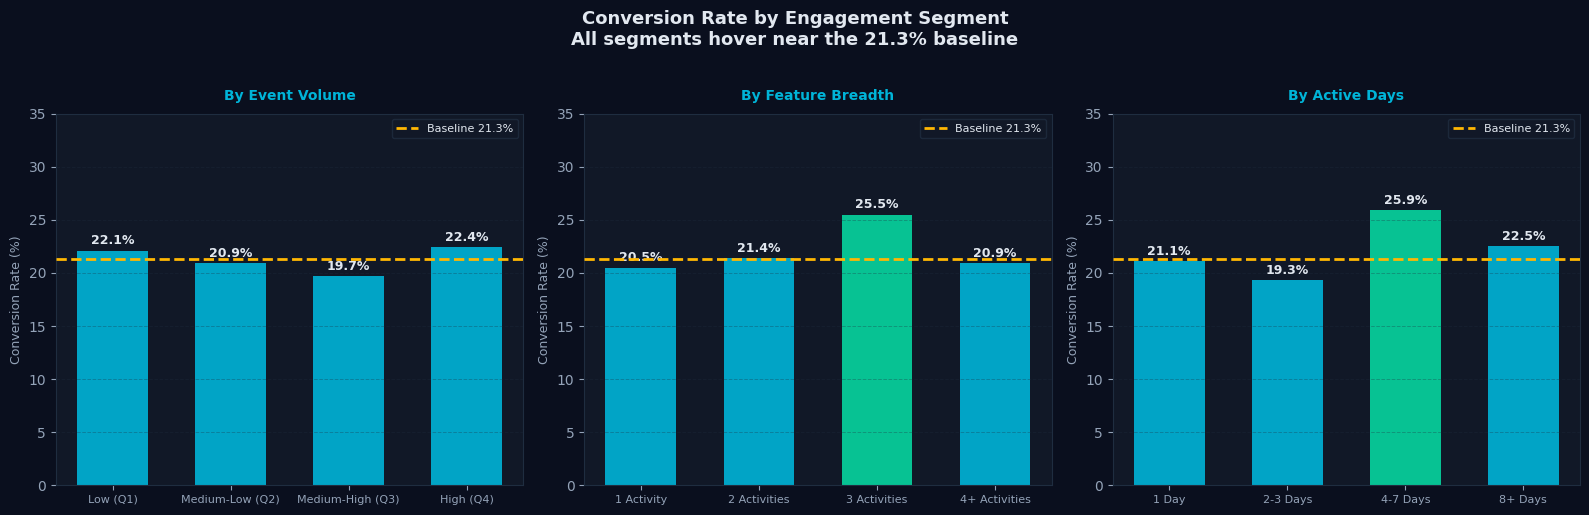

Chart saved: assets/05_segmentation.png


In [25]:
# ── CELL 21: SEGMENTATION VISUALISATION ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Conversion Rate by Engagement Segment\n'
             'All segments hover near the 21.3% baseline',
             color=TEXT, fontsize=13, fontweight='bold', y=1.02)

baseline = 21.3

def draw_segment_chart(ax, data, title, seg_col='segment'):
    ax.set_facecolor(SURFACE)

    segments  = data[seg_col].astype(str)
    conv_rates = data['conv_rate_pct'].values
    colors = [MINT if v > baseline + 2
              else RED if v < baseline - 2
              else CYAN for v in conv_rates]

    bars = ax.bar(segments, conv_rates,
                  color=colors, alpha=0.9,
                  edgecolor='none', width=0.6)

    # Baseline line
    ax.axhline(baseline, color=AMBER, linewidth=2,
               linestyle='--', label=f'Baseline {baseline}%',
               zorder=5)

    # Value labels
    for bar, val in zip(bars, conv_rates):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%', ha='center', va='bottom',
                color=TEXT, fontsize=9, fontweight='bold')

    ax.set_title(title, color=CYAN, fontsize=10,
                 fontweight='bold', pad=10)
    ax.set_ylabel('Conversion Rate (%)',
                  color=MUTED, fontsize=9)
    ax.set_ylim(0, 35)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[:].set_color(GRID)
    ax.tick_params(axis='x', labelsize=8)

draw_segment_chart(axes[0], seg_conv,
                   'By Event Volume')
draw_segment_chart(axes[1], breadth_conv,
                   'By Feature Breadth')
draw_segment_chart(axes[2], days_conv,
                   'By Active Days')

plt.tight_layout()
plt.savefig('assets/05_segmentation.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart saved: assets/05_segmentation.png")

In [26]:
# ── CELL 22: TRIAL GOAL DEFINITION AND COMPLETION RATES ──

# ── GOAL 1: Core Scheduling Activation ──
# Org creates at least 5 shifts within first 14 days
early_shifts = df[df['days_into_trial'] <= 14].groupby(
    'organization_id'
).apply(
    lambda x: (x['activity_name'] == 
               'Scheduling.Shift.Created').sum()
).reset_index()
early_shifts.columns = ['organization_id', 'shifts_in_first_14']

org_df = org_df.merge(early_shifts, on='organization_id', how='left')
org_df['shifts_in_first_14'] = org_df['shifts_in_first_14'].fillna(0)
org_df['goal_1_met'] = org_df['shifts_in_first_14'] >= 5

# ── GOAL 2: Multi-Module Engagement ──
# Define modules
scheduling_acts = [
    'Scheduling.Shift.Created',
    'Scheduling.Shift.AssignmentChanged',
    'Scheduling.Template.ApplyModal.Applied',
    'Scheduling.OpenShiftRequest.Created',
    'Scheduling.Availability.Set',
    'Mobile.Schedule.Loaded'
]
time_tracking_acts = [
    'PunchClock.PunchedIn',
    'PunchClock.PunchedOut',
    'PunchClock.Entry.Edited',
    'Break.Activate.Started',
    'Break.Activate.Finished'
]
approval_acts = [
    'Scheduling.Shift.Approved',
    'Timesheets.BulkApprove.Confirmed',
    'Absence.Request.Approved',
    'Absence.Request.Rejected'
]
comms_acts = [
    'Communication.Message.Created'
]

def used_module(row, acts):
    return any(row.get(a, 0) > 0 for a in acts)

org_df['used_scheduling']    = org_df.apply(
    lambda r: used_module(r, scheduling_acts), axis=1)
org_df['used_time_tracking'] = org_df.apply(
    lambda r: used_module(r, time_tracking_acts), axis=1)
org_df['used_approvals']     = org_df.apply(
    lambda r: used_module(r, approval_acts), axis=1)
org_df['used_comms']         = org_df.apply(
    lambda r: used_module(r, comms_acts), axis=1)

org_df['modules_used'] = (
    org_df['used_scheduling'].astype(int) +
    org_df['used_time_tracking'].astype(int) +
    org_df['used_approvals'].astype(int) +
    org_df['used_comms'].astype(int)
)

org_df['goal_2_met'] = org_df['modules_used'] >= 2

# ── GOAL 3: End-to-End Workflow Completion ──
# Created a shift AND (approved it OR punched in OR loaded schedule)
org_df['goal_3_met'] = (
    (org_df['Scheduling.Shift.Created'] > 0) &
    (
        (org_df['Scheduling.Shift.Approved'] > 0) |
        (org_df['PunchClock.PunchedIn'] > 0) |
        (org_df['Mobile.Schedule.Loaded'] > 0)
    )
)

# ── TRIAL ACTIVATION ──
# Must meet ALL three goals
org_df['trial_activated'] = (
    org_df['goal_1_met'] &
    org_df['goal_2_met'] &
    org_df['goal_3_met']
)

# ── COMPLETION RATES ──
print("=" * 60)
print("TRIAL GOAL COMPLETION RATES")
print("=" * 60)

for goal, col in [('Goal 1 — Core Scheduling (5+ shifts, day 1-14)',
                   'goal_1_met'),
                  ('Goal 2 — Multi-Module (2+ modules)',
                   'goal_2_met'),
                  ('Goal 3 — End-to-End Workflow',
                   'goal_3_met'),
                  ('TRIAL ACTIVATED (all 3 goals)',
                   'trial_activated')]:

    total    = org_df[col].sum()
    rate     = org_df[col].mean() * 100

    conv_rate = org_df[org_df[col]==True]['converted'].mean()*100
    nonconv_rate = org_df[org_df[col]==False]['converted'].mean()*100

    print(f"\n{goal}")
    print(f"  Orgs completing:          {total} ({rate:.1f}%)")
    print(f"  Conv rate if completed:   {conv_rate:.1f}%")
    print(f"  Conv rate if not:         {nonconv_rate:.1f}%")
    print(f"  Lift:                     "
          f"{conv_rate/nonconv_rate:.2f}x"
          if nonconv_rate > 0 else "  Lift: N/A")

TRIAL GOAL COMPLETION RATES

Goal 1 — Core Scheduling (5+ shifts, day 1-14)
  Orgs completing:          431 (44.6%)
  Conv rate if completed:   21.8%
  Conv rate if not:         20.9%
  Lift:                     1.04x

Goal 2 — Multi-Module (2+ modules)
  Orgs completing:          339 (35.1%)
  Conv rate if completed:   22.1%
  Conv rate if not:         20.9%
  Lift:                     1.06x

Goal 3 — End-to-End Workflow
  Orgs completing:          420 (43.5%)
  Conv rate if completed:   21.9%
  Conv rate if not:         20.9%
  Lift:                     1.05x

TRIAL ACTIVATED (all 3 goals)
  Orgs completing:          235 (24.3%)
  Conv rate if completed:   23.4%
  Conv rate if not:         20.7%
  Lift:                     1.13x


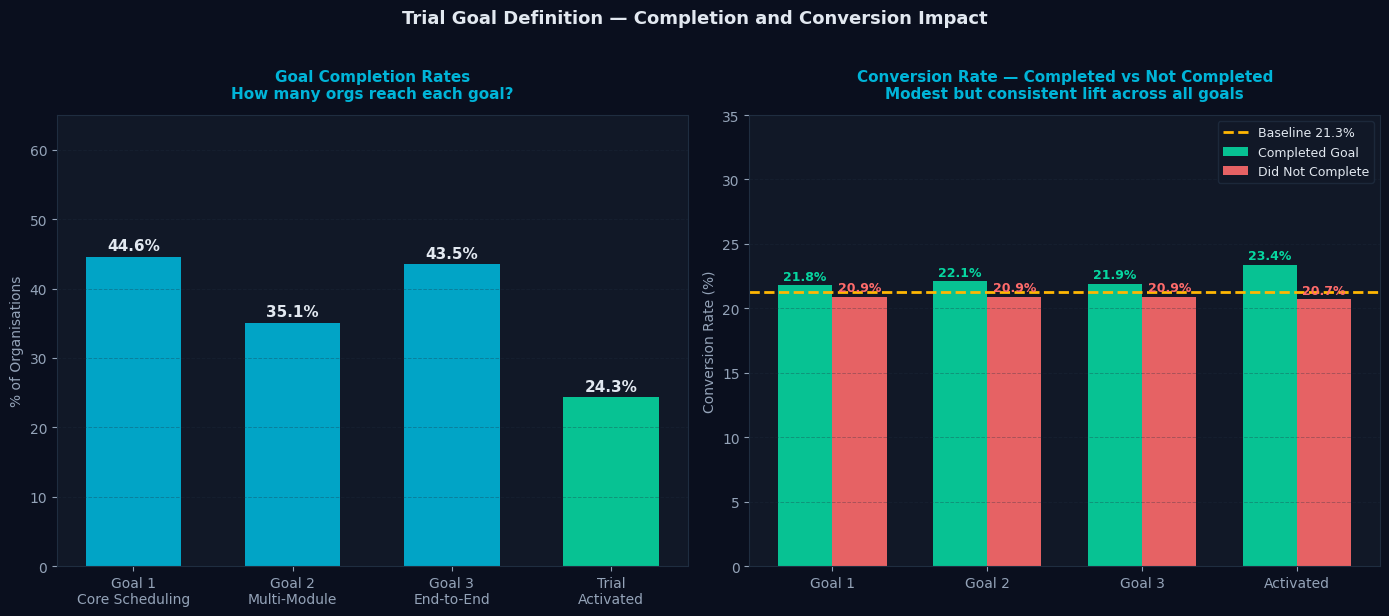

Chart saved: assets/06_goal_completion.png


In [27]:
# ── CELL 23: GOAL COMPLETION VISUALISATION ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Trial Goal Definition — Completion and Conversion Impact',
             color=TEXT, fontsize=13, fontweight='bold', y=1.02)

# ── CHART 1: Completion rates ──
ax1 = axes[0]
ax1.set_facecolor(SURFACE)

goals  = ['Goal 1\nCore Scheduling', 'Goal 2\nMulti-Module',
          'Goal 3\nEnd-to-End', 'Trial\nActivated']
rates  = [44.6, 35.1, 43.5, 24.3]
colors = [CYAN, CYAN, CYAN, MINT]

bars = ax1.bar(goals, rates, color=colors,
               alpha=0.9, edgecolor='none', width=0.6)

for bar, val in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom',
             color=TEXT, fontsize=11, fontweight='bold')

ax1.set_ylabel('% of Organisations', color=MUTED, fontsize=10)
ax1.set_title('Goal Completion Rates\nHow many orgs reach each goal?',
              color=CYAN, fontsize=11, fontweight='bold', pad=12)
ax1.set_ylim(0, 65)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[:].set_color(GRID)

# ── CHART 2: Conversion rate — completed vs not ──
ax2 = axes[1]
ax2.set_facecolor(SURFACE)

labels    = ['Goal 1', 'Goal 2', 'Goal 3', 'Activated']
completed = [21.8, 22.1, 21.9, 23.4]
not_comp  = [20.9, 20.9, 20.9, 20.7]

x     = np.arange(len(labels))
width = 0.35

bars1 = ax2.bar(x - width/2, completed, width,
                color=MINT, alpha=0.9,
                label='Completed Goal', edgecolor='none')
bars2 = ax2.bar(x + width/2, not_comp, width,
                color=RED, alpha=0.9,
                label='Did Not Complete', edgecolor='none')

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%',
             ha='center', va='bottom',
             color=MINT, fontsize=9, fontweight='bold')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%',
             ha='center', va='bottom',
             color=RED, fontsize=9, fontweight='bold')

ax2.axhline(21.3, color=AMBER, linewidth=2,
            linestyle='--', label='Baseline 21.3%')

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel('Conversion Rate (%)', color=MUTED, fontsize=10)
ax2.set_title('Conversion Rate — Completed vs Not Completed\n'
              'Modest but consistent lift across all goals',
              color=CYAN, fontsize=11, fontweight='bold', pad=12)
ax2.set_ylim(0, 35)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[:].set_color(GRID)

plt.tight_layout()
plt.savefig('assets/06_goal_completion.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart saved: assets/06_goal_completion.png")

In [28]:
# ── CELL 24: BUILD SQLITE DATABASE AND EXECUTE SQL MODELS ──
import sqlite3
import os

# ── CREATE DATABASE ──
conn = sqlite3.connect('data/splendor.db')
cursor = conn.cursor()

# ── LOAD CLEAN EVENTS INTO DATABASE ──
# Load clean events as the raw_events table
clean_df = pd.read_csv('data/clean_events.csv')
clean_df.to_sql('raw_events', conn,
                if_exists='replace', index=False)
print(f"raw_events table created: {len(clean_df):,} rows")

# ── EXECUTE STAGING MODEL ──
# Read stg_events.sql and adapt for SQLite execution
# SQLite does not support CREATE TABLE AS with CTEs directly
# so we execute as a view

stg_sql = """
CREATE VIEW IF NOT EXISTS stg_events AS

WITH raw AS (
    SELECT
        ORGANIZATION_ID                                         AS organization_id,
        ACTIVITY_NAME                                           AS activity_name,
        TIMESTAMP                                               AS event_timestamp,
        TRIAL_START                                             AS trial_start,
        TRIAL_END                                               AS trial_end,
        CONVERTED                                               AS converted,
        CONVERTED_AT                                            AS converted_at
    FROM raw_events
),

deduplicated AS (
    SELECT DISTINCT
        organization_id,
        activity_name,
        event_timestamp,
        trial_start,
        trial_end,
        converted,
        converted_at
    FROM raw
),

with_derived AS (
    SELECT
        organization_id,
        activity_name,
        event_timestamp,
        trial_start,
        trial_end,
        converted,
        converted_at,

        CAST(
            JULIANDAY(event_timestamp) - JULIANDAY(trial_start)
        AS INTEGER)                                             AS days_into_trial,

        CASE
            WHEN converted_at IS NOT NULL
            THEN CAST(
                JULIANDAY(converted_at) - JULIANDAY(trial_start)
            AS INTEGER)
            ELSE NULL
        END                                                     AS days_to_convert,

        CAST(
            JULIANDAY(trial_end) - JULIANDAY(trial_start)
        AS INTEGER)                                             AS trial_duration_days,

        CASE
            WHEN CAST(
                JULIANDAY(event_timestamp) - JULIANDAY(trial_start)
            AS INTEGER) <= 14
            THEN 1 ELSE 0
        END                                                     AS is_early_trial

    FROM deduplicated
    WHERE event_timestamp >= trial_start
      AND event_timestamp <= trial_end
)

SELECT * FROM with_derived
"""

cursor.execute("DROP VIEW IF EXISTS stg_events")
cursor.execute(stg_sql)
conn.commit()

# Verify staging view
stg_count = pd.read_sql_query(
    "SELECT COUNT(*) as rows FROM stg_events", conn)
print(f"stg_events view created: {stg_count['rows'].values[0]:,} rows")

# ── EXECUTE TRIAL GOALS MART ──
trial_goals_sql = open(
    'sql/marts/trial_goals.sql', 'r').read()

# Execute as a materialised table
goals_query = """
CREATE TABLE IF NOT EXISTS trial_goals AS

WITH org_base AS (
    SELECT
        organization_id,
        MAX(CAST(converted AS INTEGER))     AS converted,
        MIN(trial_start)                    AS trial_start,
        MIN(trial_end)                      AS trial_end,
        MIN(converted_at)                   AS converted_at,
        MIN(days_to_convert)                AS days_to_convert,
        COUNT(*)                            AS total_events,
        COUNT(DISTINCT activity_name)       AS unique_activities,
        COUNT(DISTINCT days_into_trial)     AS active_days
    FROM stg_events
    GROUP BY organization_id
),

goal_1 AS (
    SELECT
        organization_id,
        SUM(CASE
            WHEN activity_name = 'Scheduling.Shift.Created'
             AND is_early_trial = 1
            THEN 1 ELSE 0
        END)                                AS shifts_in_first_14_days,
        CASE
            WHEN SUM(CASE
                WHEN activity_name = 'Scheduling.Shift.Created'
                 AND is_early_trial = 1
                THEN 1 ELSE 0
            END) >= 5
            THEN 1 ELSE 0
        END                                 AS goal_1_met
    FROM stg_events
    GROUP BY organization_id
),

goal_2 AS (
    SELECT
        organization_id,
        MAX(CASE WHEN activity_name IN (
            'Scheduling.Shift.Created',
            'Scheduling.Shift.AssignmentChanged',
            'Scheduling.Template.ApplyModal.Applied',
            'Scheduling.OpenShiftRequest.Created',
            'Scheduling.Availability.Set',
            'Mobile.Schedule.Loaded'
        ) THEN 1 ELSE 0 END)                AS used_scheduling,
        MAX(CASE WHEN activity_name IN (
            'PunchClock.PunchedIn',
            'PunchClock.PunchedOut',
            'PunchClock.Entry.Edited',
            'Break.Activate.Started',
            'Break.Activate.Finished'
        ) THEN 1 ELSE 0 END)                AS used_time_tracking,
        MAX(CASE WHEN activity_name IN (
            'Scheduling.Shift.Approved',
            'Timesheets.BulkApprove.Confirmed',
            'Absence.Request.Approved',
            'Absence.Request.Rejected'
        ) THEN 1 ELSE 0 END)                AS used_approvals,
        MAX(CASE WHEN activity_name IN (
            'Communication.Message.Created'
        ) THEN 1 ELSE 0 END)                AS used_communications
    FROM stg_events
    GROUP BY organization_id
),

goal_2_scored AS (
    SELECT
        organization_id,
        used_scheduling,
        used_time_tracking,
        used_approvals,
        used_communications,
        (used_scheduling + used_time_tracking +
         used_approvals + used_communications) AS modules_used,
        CASE
            WHEN (used_scheduling + used_time_tracking +
                  used_approvals + used_communications) >= 2
            THEN 1 ELSE 0
        END                                 AS goal_2_met
    FROM goal_2
),

goal_3 AS (
    SELECT
        organization_id,
        MAX(CASE WHEN activity_name = 'Scheduling.Shift.Created'
            THEN 1 ELSE 0 END)              AS created_shift,
        MAX(CASE WHEN activity_name IN (
            'Scheduling.Shift.Approved',
            'PunchClock.PunchedIn',
            'Mobile.Schedule.Loaded'
        ) THEN 1 ELSE 0 END)                AS completed_downstream,
        CASE
            WHEN MAX(CASE WHEN activity_name =
                'Scheduling.Shift.Created'
                THEN 1 ELSE 0 END) = 1
            AND MAX(CASE WHEN activity_name IN (
                'Scheduling.Shift.Approved',
                'PunchClock.PunchedIn',
                'Mobile.Schedule.Loaded'
            ) THEN 1 ELSE 0 END) = 1
            THEN 1 ELSE 0
        END                                 AS goal_3_met
    FROM stg_events
    GROUP BY organization_id
)

SELECT
    b.organization_id,
    b.converted,
    b.trial_start,
    b.trial_end,
    b.converted_at,
    b.days_to_convert,
    b.total_events,
    b.unique_activities,
    b.active_days,
    g1.shifts_in_first_14_days,
    g1.goal_1_met,
    g2.used_scheduling,
    g2.used_time_tracking,
    g2.used_approvals,
    g2.used_communications,
    g2.modules_used,
    g2.goal_2_met,
    g3.created_shift,
    g3.completed_downstream,
    g3.goal_3_met,
    (g1.goal_1_met + g2.goal_2_met + g3.goal_3_met) AS goals_completed
FROM org_base           b
LEFT JOIN goal_1        g1 ON b.organization_id = g1.organization_id
LEFT JOIN goal_2_scored g2 ON b.organization_id = g2.organization_id
LEFT JOIN goal_3        g3 ON b.organization_id = g3.organization_id
ORDER BY b.organization_id
"""

cursor.execute("DROP TABLE IF EXISTS trial_goals")
cursor.execute(goals_query)
conn.commit()

goals_count = pd.read_sql_query(
    "SELECT COUNT(*) as rows FROM trial_goals", conn)
print(f"trial_goals table created: "
      f"{goals_count['rows'].values[0]:,} rows")

# ── EXECUTE TRIAL ACTIVATION MART ──
activation_query = """
CREATE TABLE IF NOT EXISTS trial_activation AS

WITH activation_base AS (
    SELECT
        organization_id,
        converted,
        trial_start,
        trial_end,
        converted_at,
        days_to_convert,
        total_events,
        unique_activities,
        active_days,
        goals_completed,
        goal_1_met,
        goal_2_met,
        goal_3_met,
        CASE
            WHEN goal_1_met = 1
             AND goal_2_met = 1
             AND goal_3_met = 1
            THEN 1 ELSE 0
        END                             AS activated
    FROM trial_goals
),

with_tiers AS (
    SELECT
        *,
        CASE
            WHEN activated = 1
                THEN 'Fully Activated'
            WHEN goals_completed = 2
                THEN 'Nearly Activated (2/3 Goals)'
            WHEN goals_completed = 1
                THEN 'Partially Activated (1/3 Goals)'
            ELSE 'Not Activated (0/3 Goals)'
        END                             AS activation_tier,
        CASE
            WHEN converted = 0
                THEN 'Not Converted'
            WHEN days_to_convert <= 7
                THEN 'Week 1'
            WHEN days_to_convert <= 14
                THEN 'Week 2'
            WHEN days_to_convert <= 21
                THEN 'Week 3'
            WHEN days_to_convert <= 30
                THEN 'Week 4'
            ELSE 'Post-Trial'
        END                             AS conversion_timing_bucket,
        CASE
            WHEN active_days = 1
                THEN 'Single Day'
            WHEN active_days BETWEEN 2 AND 3
                THEN 'Early Dropout'
            WHEN active_days BETWEEN 4 AND 7
                THEN 'Moderate Engagement'
            ELSE 'High Engagement'
        END                             AS engagement_bucket
    FROM activation_base
)

SELECT
    organization_id,
    activated,
    activation_tier,
    goals_completed,
    goal_1_met,
    goal_2_met,
    goal_3_met,
    converted,
    converted_at,
    days_to_convert,
    conversion_timing_bucket,
    trial_start,
    trial_end,
    total_events,
    unique_activities,
    active_days,
    engagement_bucket
FROM with_tiers
ORDER BY activated DESC, goals_completed DESC, organization_id ASC
"""

cursor.execute("DROP TABLE IF EXISTS trial_activation")
cursor.execute(activation_query)
conn.commit()

act_count = pd.read_sql_query(
    "SELECT COUNT(*) as rows FROM trial_activation", conn)
print(f"trial_activation table created: "
      f"{act_count['rows'].values[0]:,} rows")

print("\n" + "="*55)
print("ALL SQL MODELS EXECUTED SUCCESSFULLY")
print("="*55)

raw_events table created: 102,895 rows
stg_events view created: 102,895 rows
trial_goals table created: 966 rows
trial_activation table created: 966 rows

ALL SQL MODELS EXECUTED SUCCESSFULLY


In [29]:
# ── CELL 25: VERIFY SQL RESULTS MATCH PYTHON ANALYSIS ──

print("=" * 55)
print("SQL MODEL VERIFICATION")
print("=" * 55)

# ── TRIAL GOALS VERIFICATION ──
goals_verify = pd.read_sql_query("""
    SELECT
        SUM(goal_1_met)                         AS goal_1_met,
        SUM(goal_2_met)                         AS goal_2_met,
        SUM(goal_3_met)                         AS goal_3_met,
        SUM(goal_1_met + goal_2_met + 
            goal_3_met = 3)                     AS all_goals_met,
        COUNT(*)                                AS total_orgs,
        ROUND(AVG(converted) * 100, 1)         AS overall_conv_rate
    FROM trial_goals
""", conn)

print("\ntrial_goals summary:")
print(goals_verify.to_string(index=False))

# ── ACTIVATION TIER BREAKDOWN ──
tier_verify = pd.read_sql_query("""
    SELECT
        activation_tier,
        COUNT(*)                                AS orgs,
        ROUND(COUNT(*) * 100.0 / 966, 1)      AS pct_of_total,
        ROUND(AVG(converted) * 100, 1)         AS conv_rate
    FROM trial_activation
    GROUP BY activation_tier
    ORDER BY orgs DESC
""", conn)

print("\ntrial_activation tier breakdown:")
print(tier_verify.to_string(index=False))

# ── CROSS CHECK WITH PYTHON ──
print("\n" + "=" * 55)
print("CROSS-CHECK: SQL vs Python")
print("=" * 55)
print(f"  Goal 1 (SQL): "
      f"{goals_verify['goal_1_met'].values[0]:.0f}  "
      f"| Python: "
      f"{org_df['goal_1_met'].sum()}")
print(f"  Goal 2 (SQL): "
      f"{goals_verify['goal_2_met'].values[0]:.0f}  "
      f"| Python: "
      f"{org_df['goal_2_met'].sum()}")
print(f"  Goal 3 (SQL): "
      f"{goals_verify['goal_3_met'].values[0]:.0f}  "
      f"| Python: "
      f"{org_df['goal_3_met'].sum()}")
print(f"  Activated (SQL): "
      f"{goals_verify['all_goals_met'].values[0]:.0f}  "
      f"| Python: "
      f"{org_df['trial_activated'].sum()}")
print(f"  Conv rate (SQL): "
      f"{goals_verify['overall_conv_rate'].values[0]}%  "
      f"| Python: 21.3%")

# ── SAMPLE ROWS ──
print("\nSample from trial_activation (first 5 rows):")
sample = pd.read_sql_query("""
    SELECT
        organization_id,
        activated,
        activation_tier,
        goals_completed,
        converted,
        engagement_bucket
    FROM trial_activation
    LIMIT 5
""", conn)
print(sample.to_string(index=False))

conn.close()
print("\nDatabase connection closed.")
print("SQL verification complete.")

SQL MODEL VERIFICATION

trial_goals summary:
 goal_1_met  goal_2_met  goal_3_met  all_goals_met  total_orgs  overall_conv_rate
        431         339         420            235         966              21.30

trial_activation tier breakdown:
                activation_tier  orgs  pct_of_total  conv_rate
      Not Activated (0/3 Goals)   370         38.30      21.40
Partially Activated (1/3 Goals)   237         24.50      20.30
                Fully Activated   235         24.30      23.40
   Nearly Activated (2/3 Goals)   124         12.80      19.40

CROSS-CHECK: SQL vs Python
  Goal 1 (SQL): 431  | Python: 431
  Goal 2 (SQL): 339  | Python: 339
  Goal 3 (SQL): 420  | Python: 420
  Activated (SQL): 235  | Python: 235
  Conv rate (SQL): 21.3%  | Python: 21.3%

Sample from trial_activation (first 5 rows):
                 organization_id  activated activation_tier  goals_completed  converted   engagement_bucket
0040dd9ab132b92d5d04bc3acf14d2e2          1 Fully Activated                

In [30]:
# ── CELL 26: PRODUCT METRICS AND DESCRIPTIVE ANALYTICS ──

print("=" * 55)
print("PRODUCT METRICS DASHBOARD")
print("=" * 55)

# ── METRIC 1: Overall Conversion Rate ──
total_orgs      = len(org_df)
converted_orgs  = org_df['converted'].sum()
conv_rate       = org_df['converted'].mean() * 100

print(f"\n── Metric 1: Conversion Rate ──")
print(f"  Total trialling orgs:    {total_orgs:,}")
print(f"  Converted orgs:          {converted_orgs:,}")
print(f"  Overall conversion rate: {conv_rate:.1f}%")

# ── METRIC 2: Time to Convert ──
converters = org_df[org_df['converted'] == True]

print(f"\n── Metric 2: Time to Convert (days) ──")
print(f"  Median: {converters['days_to_convert'].median():.0f} days")
print(f"  Mean:   {converters['days_to_convert'].mean():.0f} days")
print(f"  Min:    {converters['days_to_convert'].min():.0f} days")
print(f"  Max:    {converters['days_to_convert'].max():.0f} days")
print(f"  Converted within trial (<=30 days): "
      f"{(converters['days_to_convert']<=30).sum()} "
      f"({(converters['days_to_convert']<=30).mean()*100:.1f}%)")
print(f"  Converted post-trial (>30 days):    "
      f"{(converters['days_to_convert']>30).sum()} "
      f"({(converters['days_to_convert']>30).mean()*100:.1f}%)")

# ── METRIC 3: Feature Adoption Rates ──
print(f"\n── Metric 3: Feature Adoption Rates ──")
print(f"  (% of all orgs that used each feature at least once)")

adoption_rates = {}
for col in activity_cols:
    rate = (org_df[col] > 0).mean() * 100
    adoption_rates[name_map.get(col, col)] = round(rate, 1)

adoption_series = pd.Series(adoption_rates).sort_values(ascending=False)
for name, rate in adoption_series.items():
    bar = '█' * int(rate / 2)
    print(f"  {name:<30} {rate:5.1f}%  {bar}")

# ── METRIC 4: Trial Activation Rate ──
activation_rate = org_df['trial_activated'].mean() * 100
print(f"\n── Metric 4: Trial Activation Rate ──")
print(f"  Activated orgs:          "
      f"{org_df['trial_activated'].sum()} ({activation_rate:.1f}%)")
print(f"  Non-activated orgs:      "
      f"{(~org_df['trial_activated']).sum()} "
      f"({100-activation_rate:.1f}%)")

# ── METRIC 5: Single Day Drop-off ──
single_day = (org_df['active_days'] == 1).sum()
single_day_pct = (org_df['active_days'] == 1).mean() * 100
print(f"\n── Metric 5: Single Day Drop-off ──")
print(f"  Orgs active only 1 day:  "
      f"{single_day} ({single_day_pct:.1f}%)")
print(f"  Their conversion rate:   "
      f"{org_df[org_df['active_days']==1]['converted'].mean()*100:.1f}%")

# ── METRIC 6: Module Adoption ──
print(f"\n── Metric 6: Module Adoption Rates ──")
print(f"  Scheduling module:    "
      f"{org_df['used_scheduling'].mean()*100:.1f}%")
print(f"  Time Tracking module: "
      f"{org_df['used_time_tracking'].mean()*100:.1f}%")
print(f"  Approvals module:     "
      f"{org_df['used_approvals'].mean()*100:.1f}%")
print(f"  Communications module:{org_df['used_comms'].mean()*100:.1f}%")

# ── METRIC 7: Cohort Conversion by Trial Start Month ──
print(f"\n── Metric 7: Conversion Rate by Trial Start Month ──")
org_df['trial_month'] = pd.to_datetime(
    org_df['trial_start']).dt.strftime('%B %Y')
monthly = org_df.groupby('trial_month')['converted'].agg(
    ['mean','count','sum']).reset_index()
monthly.columns = ['month','conv_rate','total','converted']
monthly['conv_rate_pct'] = (monthly['conv_rate']*100).round(1)
print(monthly[['month','total',
               'converted','conv_rate_pct']].to_string(index=False))

PRODUCT METRICS DASHBOARD

── Metric 1: Conversion Rate ──
  Total trialling orgs:    966
  Converted orgs:          206
  Overall conversion rate: 21.3%

── Metric 2: Time to Convert (days) ──
  Median: 30 days
  Mean:   30 days
  Min:    14 days
  Max:    64 days
  Converted within trial (<=30 days): 105 (51.0%)
  Converted post-trial (>30 days):    101 (49.0%)

── Metric 3: Feature Adoption Rates ──
  (% of all orgs that used each feature at least once)
  Shift Created                   87.8%  ███████████████████████████████████████████
  Schedule Loaded                 47.2%  ███████████████████████
  Assignment Changed              35.5%  █████████████████
  Punched In                      21.8%  ██████████
  Shift Approved                  20.7%  ██████████
  Message Created                 15.0%  ███████
  Template Applied                11.2%  █████
  Availability Set                 6.1%  ███
  Shift Details Opened             4.7%  ██
  Open Shift Created               4.5%  

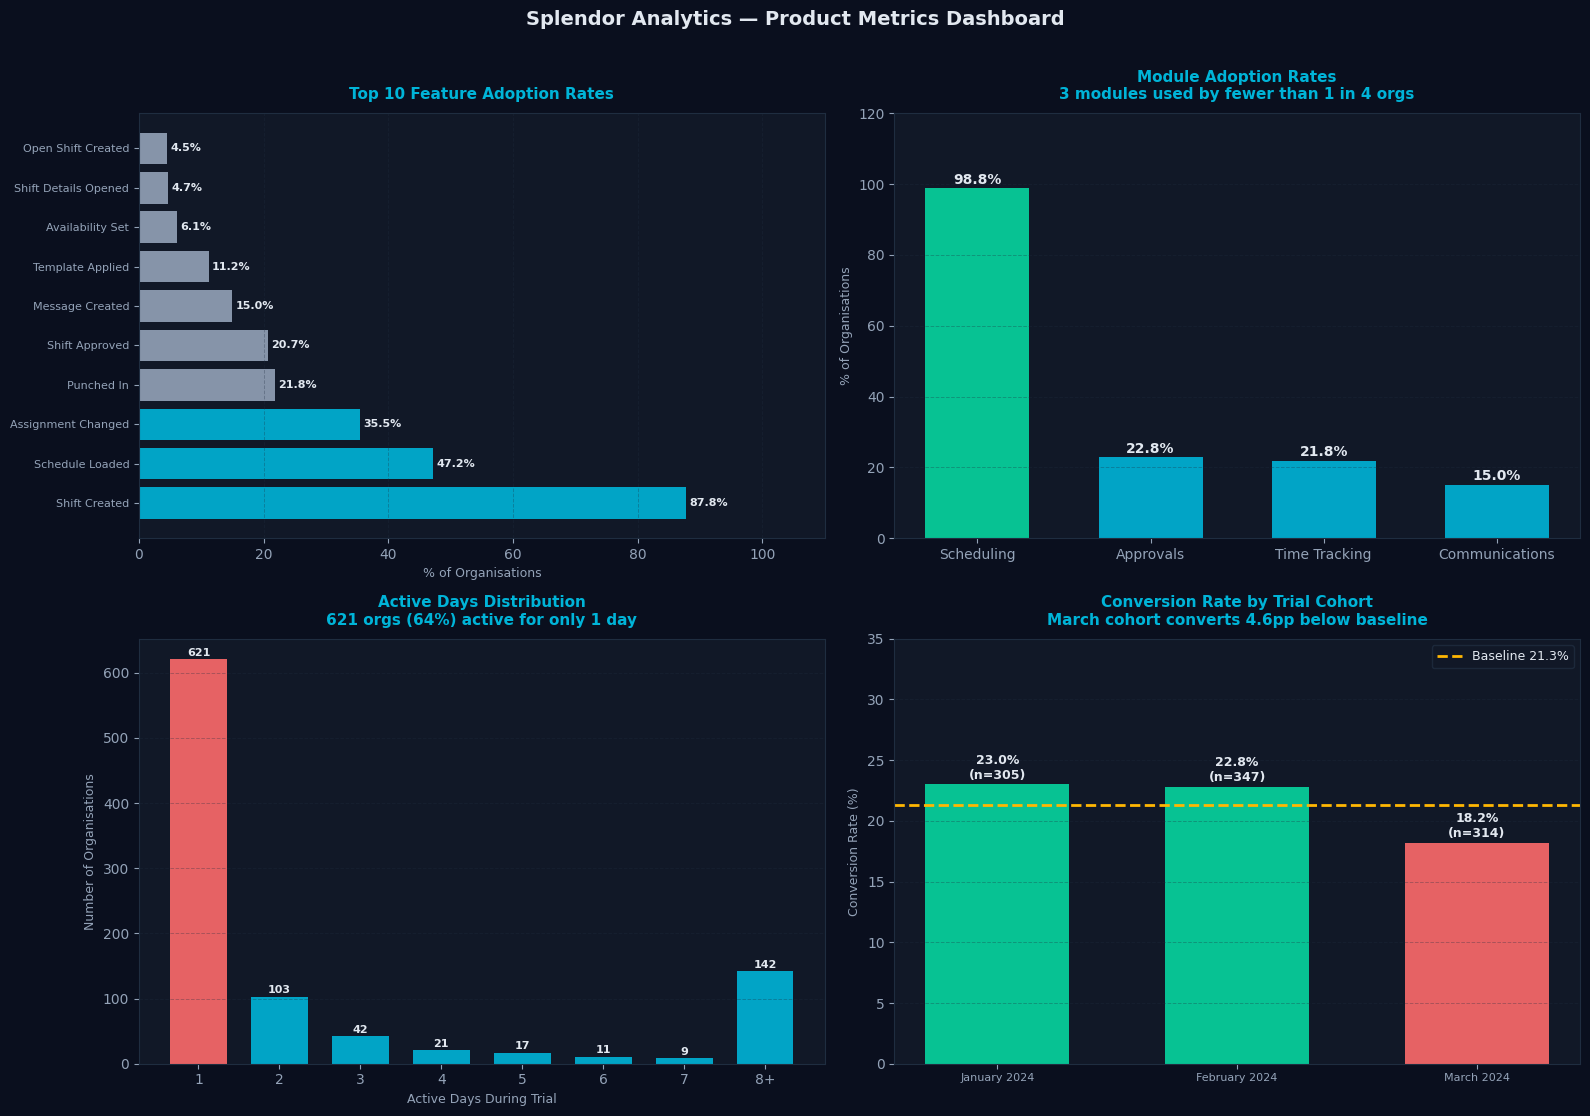

Chart saved: assets/07_product_metrics.png


In [32]:
# ── CELL 27: PRODUCT METRICS VISUALISATION ──

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(BG)
fig.suptitle('Splendor Analytics — Product Metrics Dashboard',
             color=TEXT, fontsize=14, fontweight='bold', y=1.01)

# ── CHART 1: Feature adoption rates (top 10) ──
ax1 = axes[0, 0]
ax1.set_facecolor(SURFACE)

top10 = adoption_series.head(10)
colors_adopt = [CYAN if i < 3 else MUTED
                for i in range(len(top10))]

bars = ax1.barh(range(len(top10)), top10.values,
                color=colors_adopt, alpha=0.9,
                edgecolor='none')

for bar, val in zip(bars, top10.values):
    ax1.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', color=TEXT,
             fontsize=8, fontweight='bold')

ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(top10.index, fontsize=8)
ax1.set_xlabel('% of Organisations', color=MUTED, fontsize=9)
ax1.set_title('Top 10 Feature Adoption Rates',
              color=CYAN, fontsize=11, fontweight='bold', pad=10)
ax1.set_xlim(0, 110)
ax1.grid(axis='x', alpha=0.3)
ax1.spines[:].set_color(GRID)

# ── CHART 2: Module adoption ──
ax2 = axes[0, 1]
ax2.set_facecolor(SURFACE)

modules = ['Scheduling', 'Approvals',
           'Time Tracking', 'Communications']
mod_rates = [98.8, 22.8, 21.8, 15.0]
mod_colors = [MINT, CYAN, CYAN, CYAN]

bars2 = ax2.bar(modules, mod_rates,
                color=mod_colors, alpha=0.9,
                edgecolor='none', width=0.6)

for bar, val in zip(bars2, mod_rates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom',
             color=TEXT, fontsize=10, fontweight='bold')

ax2.set_ylabel('% of Organisations', color=MUTED, fontsize=9)
ax2.set_title('Module Adoption Rates\n'
              '3 modules used by fewer than 1 in 4 orgs',
              color=CYAN, fontsize=11, fontweight='bold', pad=10)
ax2.set_ylim(0, 120)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[:].set_color(GRID)

# ── CHART 3: Active days distribution ──
ax3 = axes[1, 0]
ax3.set_facecolor(SURFACE)

active_days_dist = org_df['active_days'].value_counts().sort_index()

# Group 8+ days together
grouped = active_days_dist.copy()
over_8  = grouped[grouped.index >= 8].sum()
grouped = grouped[grouped.index < 8]
grouped[8] = over_8
grouped = grouped.sort_index()

day_labels = [str(i) if i < 8 else '8+' 
              for i in grouped.index]
bar_colors = [RED if i == 1 else CYAN 
              for i in grouped.index]

bars3 = ax3.bar(day_labels, grouped.values,
                color=bar_colors, alpha=0.9,
                edgecolor='none', width=0.7)

for bar, val in zip(bars3, grouped.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(val), ha='center', va='bottom',
             color=TEXT, fontsize=8, fontweight='bold')

ax3.set_xlabel('Active Days During Trial',
               color=MUTED, fontsize=9)
ax3.set_ylabel('Number of Organisations',
               color=MUTED, fontsize=9)
ax3.set_title('Active Days Distribution\n'
              '621 orgs (64%) active for only 1 day',
              color=CYAN, fontsize=11, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[:].set_color(GRID)

# ── CHART 4: Monthly cohort conversion ──
ax4 = axes[1, 1]
ax4.set_facecolor(SURFACE)

months     = ['January 2024', 'February 2024', 'March 2024']
conv_rates_m = [23.0, 22.8, 18.2]
total_m    = [305, 347, 314]
bar_colors4 = [MINT, MINT, RED]

bars4 = ax4.bar(months, conv_rates_m,
                color=bar_colors4, alpha=0.9,
                edgecolor='none', width=0.6)

for bar, val, tot in zip(bars4, conv_rates_m, total_m):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val}%\n(n={tot})',
             ha='center', va='bottom',
             color=TEXT, fontsize=9, fontweight='bold')

ax4.axhline(21.3, color=AMBER, linewidth=2,
            linestyle='--', label='Baseline 21.3%')

ax4.set_ylabel('Conversion Rate (%)',
               color=MUTED, fontsize=9)
ax4.set_title('Conversion Rate by Trial Cohort\n'
              'March cohort converts 4.6pp below baseline',
              color=CYAN, fontsize=11, fontweight='bold', pad=10)
ax4.set_ylim(0, 35)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.spines[:].set_color(GRID)
ax4.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('assets/07_product_metrics.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart saved: assets/07_product_metrics.png")